In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d


In [2]:

# ============================================================================
# CONFIGURATION
# ============================================================================
DATA_DIR = "DM_distribution_real_data"
SAVE_PLOT = False

# List of telescopes/surveys to compare
TELESCOPES = [
    "apertif",
    "askap_flyeye",
    "askap_ics",
    "dsa-110",
    "fast",
    "parkes"
]

# Define colors for each telescope (consistent across plots)
TELESCOPE_COLORS = {
    "apertif": "#3484bd",
    "askap_flyeye": "#ff7f0e",
    "askap_ics": "#2ca02c",
    "dsa-110": "#d62728",
    "fast": "#9467bd",
    "parkes": "#8c564b"
}

# ============================================================================
# LOAD DATA FROM REAL DATA DIRECTORY (WITH ERROR HANDLING)
# ============================================================================
data_dict = {}
for telescope in TELESCOPES:
    filename = f"{telescope}.csv"
    filepath = os.path.join(DATA_DIR, filename)
    
    if os.path.exists(filepath):
        try:
            # Try standard comma delimiter first
            df = pd.read_csv(filepath)
            data_dict[telescope] = df
            print(f"✓ Loaded {telescope:20s} - {len(df)} FRBs")
        except pd.errors.ParserError:
            try:
                # Try with error_bad_lines parameter (skip problematic rows)
                df = pd.read_csv(filepath, on_bad_lines='skip')
                data_dict[telescope] = df
                print(f"✓ Loaded {telescope:20s} - {len(df)} FRBs (skipped bad lines)")
            except Exception as e:
                print(f"✗ Error loading {telescope:20s}: {str(e)[:60]}")
        except Exception as e:
            print(f"✗ Error loading {telescope:20s}: {str(e)[:60]}")
    else:
        print(f"✗ Not found: {filename}")

print(f"\nTotal telescopes loaded: {len(data_dict)}")

# Display column names for loaded files
print("\n" + "="*100)
print("COLUMNS IN LOADED FILES:")
print("="*100)
for telescope, df in data_dict.items():
    print(f"{telescope:20s}: {df.columns.tolist()}")

✓ Loaded apertif              - 24 FRBs
✓ Loaded askap_flyeye         - 20 FRBs
✓ Loaded askap_ics            - 43 FRBs
✓ Loaded dsa-110              - 11 FRBs
✓ Loaded fast                 - 9 FRBs
✓ Loaded parkes               - 10 FRBs

Total telescopes loaded: 6

COLUMNS IN LOADED FILES:
apertif             : ['TNS_Name', 'DM', 'DM_err']
askap_flyeye        : ['TNS_Name', 'Time_TAI', 'Time_err', 'DM', 'DM_err', 'Fluence_Jyms', 'Fluence_err', 'RA_hhmm', 'RA_err', 'Dec_ddmm', 'Dec_err', 'gl_deg', 'gb_deg', 'Width_ms', 'Width_err', 'S/N', 'T_obs_d', 'T_15_h']
askap_ics           : ['TNS_Name', 'UTC', 'nu_c_MHz', 'N_ant', 'DM', 'DM_err', 'DM_MW', 'z', 'S/N', 'Width_ms', 'Width_err', 'Fluence_Jyms', 'Fluence_err']
dsa-110             : ['TNS_Name', 'MJD_barycentric', 'RA', 'Dec', 'RA_err', 'Dec_err', 'S/N', 'Fluence_Jyms', 'DM', 'DM_err', 'DM_ISM', 'Width_ms']
fast                : ['TNS_Name', 'DM', 'DM_NE2001', 'S/N']
parkes              : ['TNS_Name', 'S/N', 'DM', 'DM_err']


apertif             : Total 24 FRBs | Valid DM: 24 | Missing DM: 0 | DM range [  246.5,  2778.0]
askap_flyeye        : Total 20 FRBs | Valid DM: 20 | Missing DM: 0 | DM range [  114.1,   991.7]
askap_ics           : Total 43 FRBs | Valid DM: 43 | Missing DM: 0 | DM range [  206.0,  1785.3]
dsa-110             : Total 11 FRBs | Valid DM: 11 | Missing DM: 0 | DM range [  111.0,   651.2]
fast                : Total 9 FRBs | Valid DM: 9 | Missing DM: 0 | DM range [ 1187.7,  2765.2]
parkes              : Total 10 FRBs | Valid DM: 10 | Missing DM: 0 | DM range [  469.9,  1629.2]


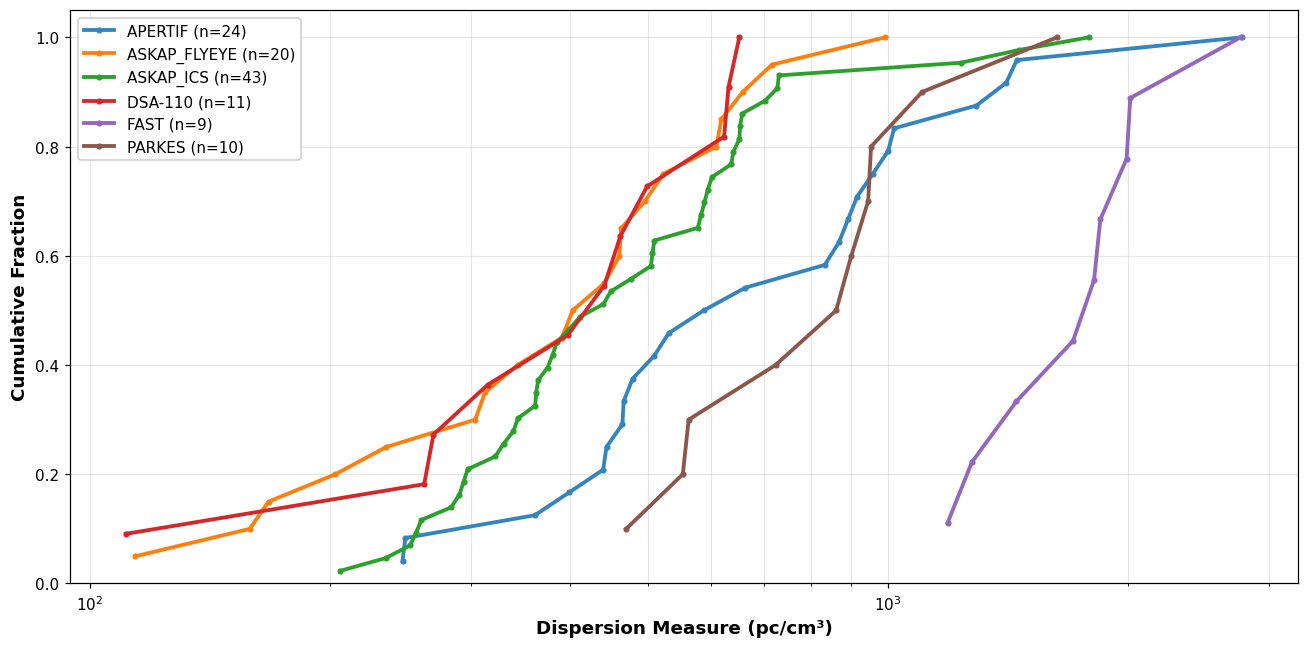


DM STATISTICS SUMMARY
   Telescope  Total_FRBs  Valid_DM  Missing_DM DM_min DM_max DM_median DM_mean DM_std
     APERTIF          24        24           0  246.5 2778.0     625.3   801.9  534.3
ASKAP_FLYEYE          20        20           0  114.1  991.7     422.0   430.5  212.5
   ASKAP_ICS          43        43           0  206.0 1785.3     440.1   522.2  309.8
     DSA-110          11        11           0  111.0  651.2     441.1   423.9  165.8
        FAST           9         9           0 1187.7 2765.2    1812.0  1782.2  446.7
      PARKES          10        10           0  469.9 1629.2     880.3   869.9  319.5


In [3]:
# ============================================================================
# EXTRACT DM VALUES AND CREATE CUMULATIVE DISTRIBUTIONS
# ============================================================================
cumulative_data = {}

for telescope, df in data_dict.items():
    # Look for DM column (might be 'DM', 'dm', 'dispersion_measure', etc.)
    dm_col = None
    for col in df.columns:
        if 'dm' in col.lower() or 'dispersion' in col.lower():
            dm_col = col
            break
    
    if dm_col is None:
        print(f"Warning: Could not find DM column for {telescope}. Columns: {df.columns.tolist()}")
        continue
    
    # Keep ALL FRBs (including those with NaN DM)
    n_total = len(df)
    
    # Extract DM values and remove NaN only for plotting
    dm_values = df[dm_col].dropna().values
    dm_values = np.sort(dm_values)
    n_valid_dm = len(dm_values)
    n_missing_dm = n_total - n_valid_dm
    
    # Calculate cumulative distribution (fraction of FRBs with valid DM)
    cumulative_fraction = np.arange(1, len(dm_values) + 1) / len(dm_values)
    
    cumulative_data[telescope] = {
        'dm': dm_values,
        'cumulative': cumulative_fraction,
        'n_total': n_total,  # Total FRBs in file
        'n_valid_dm': n_valid_dm,  # FRBs with valid DM
        'n_missing_dm': n_missing_dm,  # FRBs with missing DM
        'dm_min': dm_values.min(),
        'dm_max': dm_values.max(),
        'dm_median': np.median(dm_values)
    }
    
    print(f"{telescope:20s}: Total {n_total} FRBs | Valid DM: {n_valid_dm} | Missing DM: {n_missing_dm} | "
          f"DM range [{dm_values.min():7.1f}, {dm_values.max():7.1f}]")

# ============================================================================
# VISUALIZATION: CUMULATIVE DM DISTRIBUTION (LOG SCALE)
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6), dpi=110)

# Log scale for DM
for telescope, data in cumulative_data.items():
    ax.semilogx(data['dm'], data['cumulative'], marker='o', markersize=3,
                linewidth=2.5, label=f"{telescope.upper()} (n={data['n_total']})",
                color=TELESCOPE_COLORS.get(telescope, None))

ax.set_xlabel('Dispersion Measure (pc/cm³)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Fraction', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(frameon=True, facecolor='white', framealpha=1, loc='best')
ax.set_ylim([0, 1.05])

plt.tight_layout()
if SAVE_PLOT:
    plt.savefig("DM_cumulative_real_data.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# STATISTICS TABLE
# ============================================================================
print("\n" + "="*100)
print("DM STATISTICS SUMMARY")
print("="*100)

stats_data = []
for telescope in TELESCOPES:
    if telescope in cumulative_data:
        data = cumulative_data[telescope]
        stats_data.append({
            'Telescope': telescope.upper(),
            'Total_FRBs': data['n_total'],
            'Valid_DM': data['n_valid_dm'],
            'Missing_DM': data['n_missing_dm'],
            'DM_min': f"{data['dm_min']:.1f}",
            'DM_max': f"{data['dm_max']:.1f}",
            'DM_median': f"{data['dm_median']:.1f}",
            'DM_mean': f"{data['dm'].mean():.1f}",
            'DM_std': f"{data['dm'].std():.1f}"
        })

df_stats = pd.DataFrame(stats_data)
print(df_stats.to_string(index=False))
print("="*100)

In [16]:
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [17]:

# ============================================================================
# CONFIGURATION
# ============================================================================
SIMULATED_DIR = "DM_distribution_new"
REAL_DIR = "DM_distribution_real_data"
ALPHA = -4  # Change this to match your simulated data

# Telescope mapping (simulated : real)
telescope_mapping = {
    'fast': 'fast',
    'parkes': 'parkes',
    'askap_flyeye': 'askap_flyeye',
    'askap_ics': 'askap_ics',
    'dsa-110': 'dsa-110',
    'apertif':'apertif',
}

# ============================================================================
# LOAD SIMULATED DM DISTRIBUTIONS
# ============================================================================
simulated_data = {}
for sim_tel in telescope_mapping.keys():
    filename = f"DM_{sim_tel}_alpha{ALPHA}_scaled.csv"
    filepath = os.path.join(SIMULATED_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        dm_simulated = df['z'].values * 1000
        simulated_data[sim_tel] = dm_simulated
        print(f"✓ Loaded simulated {sim_tel:20s} - {len(dm_simulated)} bins")

# ============================================================================
# LOAD REAL DM DISTRIBUTIONS
# ============================================================================
real_data = {}
for real_tel in telescope_mapping.values():
    filename = f"{real_tel}.csv"
    filepath = os.path.join(REAL_DIR, filename)
    
    if os.path.exists(filepath):
        try:
            df = pd.read_csv(filepath, engine='python', on_bad_lines='warn')
            
            dm_col = None
            for col in df.columns:
                if 'dm' in col.lower() or 'dispersion' in col.lower():
                    dm_col = col
                    break
            
            if dm_col is not None:
                dm_real = df[dm_col].dropna().values
                real_data[real_tel] = dm_real
                print(f"✓ Loaded real {real_tel:20s} - {len(dm_real)} FRBs")
        except Exception as e:
            print(f"✗ Error loading {real_tel}: {str(e)[:60]}")


✓ Loaded simulated fast                 - 499 bins
✓ Loaded simulated parkes               - 239 bins
✓ Loaded simulated askap_flyeye         - 100 bins
✓ Loaded simulated askap_ics            - 196 bins
✓ Loaded simulated dsa-110              - 183 bins
✓ Loaded simulated apertif              - 233 bins
✓ Loaded real fast                 - 9 FRBs
✓ Loaded real parkes               - 10 FRBs
✓ Loaded real askap_flyeye         - 20 FRBs
✓ Loaded real askap_ics            - 43 FRBs
✓ Loaded real dsa-110              - 11 FRBs
✓ Loaded real apertif              - 24 FRBs


In [18]:
# ============================================================================
# KS TEST RESULTS (Population-Weighted Simulated vs Real)
# ============================================================================
print("\n" + "="*100)
print("KS TEST RESULTS (Population-Weighted Simulated vs Real)")
print("="*100)

same_tel_ks_weighted = []
for sim_tel, real_tel in telescope_mapping.items():
    if sim_tel not in simulated_data or real_tel not in real_data:
        continue
    
    # Load simulated data with population weights
    filename = f"DM_{sim_tel}_alpha{ALPHA}_scaled.csv"
    filepath = os.path.join(SIMULATED_DIR, filename)
    sim_df = pd.read_csv(filepath)
    
    sim_dm = sim_df['z'].values * 1000
    sim_pop = sim_df['n_total_population_scaled'].values
    
    # Sort by DM and get population-weighted cumulative
    sort_idx = np.argsort(sim_dm)
    sim_dm_sorted = sim_dm[sort_idx]
    sim_pop_sorted = sim_pop[sort_idx]
    sim_cumulative_weighted = np.cumsum(sim_pop_sorted) / np.cumsum(sim_pop_sorted)[-1]
    
    # Real data (unweighted)
    real_dm = real_data[real_tel]
    real_cumulative = np.arange(1, len(real_dm) + 1) / len(real_dm)
    
    # Perform KS test
    statistic, p_value = ks_2samp(sim_dm_sorted, real_dm)
    
    same_tel_ks_weighted.append({
        'Telescope': sim_tel.upper(),
        'Simulated_N': len(sim_dm),
        'Real_N': len(real_dm),
        'KS_Statistic': statistic,
        'P_Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })
    
    print(f"{sim_tel.upper():20s} | KS: {statistic:.4f} | p-value: {p_value:.6f} | Sig: {'Yes' if p_value < 0.05 else 'No'}")

print("="*100)


KS TEST RESULTS (Population-Weighted Simulated vs Real)
FAST                 | KS: 0.4861 | p-value: 0.019189 | Sig: Yes
PARKES               | KS: 0.4397 | p-value: 0.033585 | Sig: Yes
ASKAP_FLYEYE         | KS: 0.2500 | p-value: 0.223509 | Sig: No
ASKAP_ICS            | KS: 0.5578 | p-value: 0.000000 | Sig: Yes
DSA-110              | KS: 0.6448 | p-value: 0.000106 | Sig: Yes
APERTIF              | KS: 0.3999 | p-value: 0.001202 | Sig: Yes


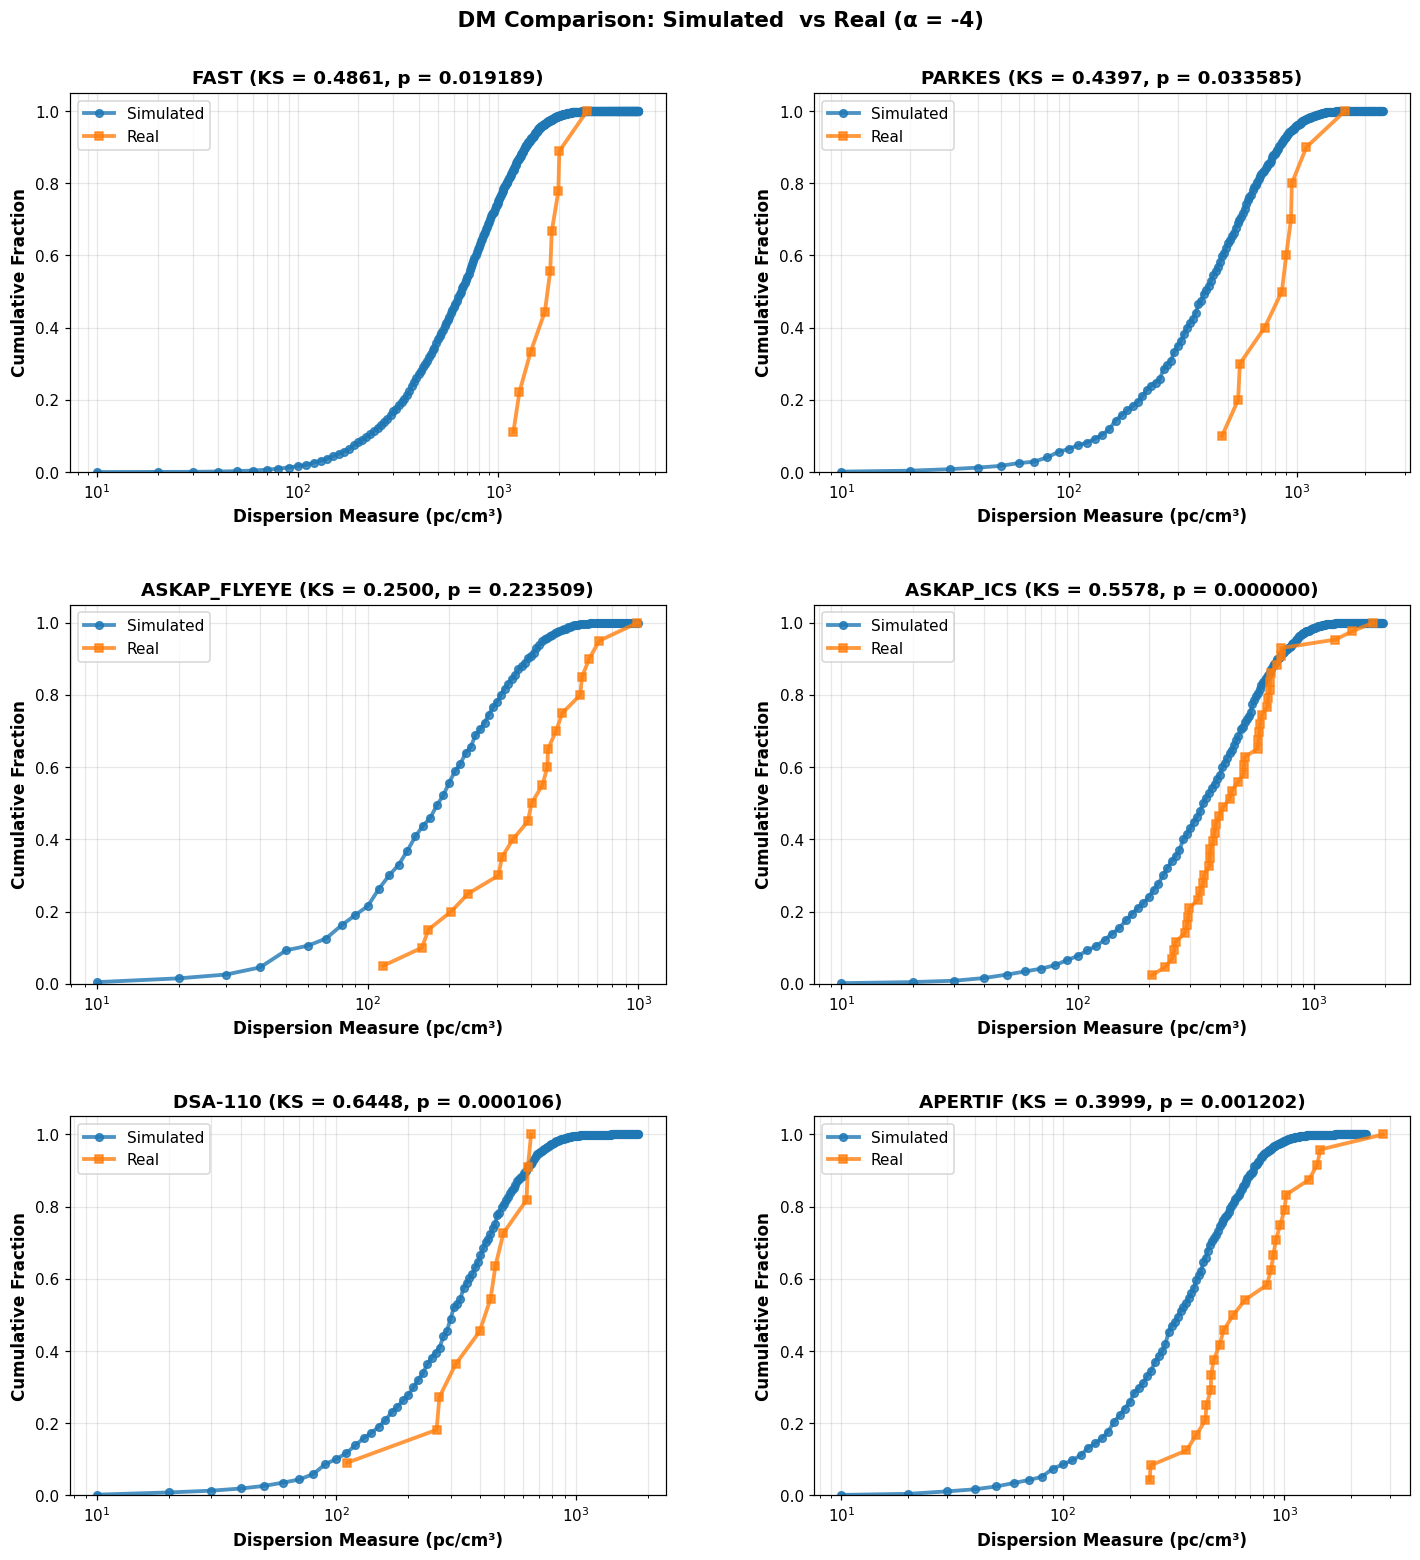

In [19]:

# ============================================================================
# VISUALIZATION: WEIGHTED DM COMPARISON (Population-Weighted Simulated)
# ============================================================================
if same_tel_ks_weighted:
    df_same_weighted = pd.DataFrame(same_tel_ks_weighted)
    n_matching = len(same_tel_ks_weighted)
    n_cols = 2
    n_rows = (n_matching + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows), dpi=110)
    if n_rows == 1:
        axes = [axes]
    axes = axes.flatten()
    
    for idx, (sim_tel, real_tel) in enumerate(telescope_mapping.items()):
        if sim_tel not in simulated_data or real_tel not in real_data:
            continue
        
        ax = axes[idx]
        
        # Load simulated with population weights
        filename = f"DM_{sim_tel}_alpha{ALPHA}_scaled.csv"
        filepath = os.path.join(SIMULATED_DIR, filename)
        sim_df = pd.read_csv(filepath)
        
        sim_dm = sim_df['z'].values * 1000
        sim_pop = sim_df['n_total_population_scaled'].values
        
        # Sort and weight
        sort_idx = np.argsort(sim_dm)
        sim_dm_sorted = sim_dm[sort_idx]
        sim_pop_sorted = sim_pop[sort_idx]
        sim_cumulative_weighted = np.cumsum(sim_pop_sorted) / np.cumsum(sim_pop_sorted)[-1]
        
        # Real data (unweighted)
        real_dm = real_data[real_tel]
        real_cumulative = np.arange(1, len(real_dm) + 1) / len(real_dm)
        
        # Plot on log scale
        ax.semilogx(sim_dm_sorted, sim_cumulative_weighted, 'o-', linewidth=2.5, 
                   markersize=5, label='Simulated', color='#1f77b4', alpha=0.8)
        ax.semilogx(np.sort(real_dm), real_cumulative, 's-', linewidth=2.5, 
                   markersize=5, label='Real', color='#ff7f0e', alpha=0.8)
        
        # Get KS statistic and p-value
        ks_val = df_same_weighted.loc[df_same_weighted['Telescope'] == sim_tel.upper(), 'KS_Statistic'].values[0]
        p_val = df_same_weighted.loc[df_same_weighted['Telescope'] == sim_tel.upper(), 'P_Value'].values[0]
        
        ax.set_xlabel('Dispersion Measure (pc/cm³)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Cumulative Fraction', fontsize=11, fontweight='bold')
        ax.set_title(f'{sim_tel.upper()} (KS = {ks_val:.4f}, p = {p_val:.6f})', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(loc='best', fontsize=10)
        ax.set_ylim([0, 1.05])
    
    # Hide extra subplots
    for idx in range(n_matching, len(axes)):
        axes[idx].set_visible(False)
    
    fig.suptitle(f' DM Comparison: Simulated  vs Real (α = {ALPHA})', 
                fontsize=14, fontweight='bold')
    
    # Use subplots_adjust instead of tight_layout (faster)
    fig.subplots_adjust(left=0.08, right=0.95, top=0.93, bottom=0.08, hspace=0.35, wspace=0.25)
    
    # plt.savefig(f"dm_comparison_weighted_alpha{ALPHA}.png", dpi=150, bbox_inches='tight')
    plt.show()